<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/03_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Início - Bibliotecas**
---

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# **Preparando dataframe**
---

In [ ]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/produtividade_locais.csv"
df = pd.read_csv(url)

# Correção para o SyntaxError: remover o '.' final
cidade = df['Municipio']

df.drop(columns=['Municipio'], inplace=True)

# Identifica colunas que podem conter valores numéricos com vírgula como separador decimal
numeric_cols_potential = ['Latitude', 'Longitude', 'Altitude'] + [col for col in df.columns if str(col).isdigit()]

for col in numeric_cols_potential:
    if col in df.columns:
        # Substitui vírgulas por pontos e converte para numérico
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce') # 'coerce' transforma erros em NaN
df["Municipio"] = cidade
df_municipios = df
df_municipios.columns

Index(['Localidade', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       'Latitude', 'Longitude', 'Altitude', 'Municipio'],
      dtype='object')

In [ ]:
# URL do arquivo CSV no GitHub
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_final.csv"

# Carrega o arquivo CSV em um DataFrame pandas
df = pd.read_csv(url)

# Cria nova coluna 'Amp' = amplitude térmica (diferença entre Tmax e Tmin)
df["Amp"] = df['Tmax'] - df['Tmin']

# Cria 'Pefetiva' = precipitação efetiva (Chuva / Evapotranspiração da cultura)
df["Pefetiva"] = df["Chuva"] / df['ETc']

# Cria 'T_DEF' = interação entre temperatura máxima e déficit hídrico
df['T_DEF'] = df['Tmax'] * df['DEF']

# Transforma dados de produção por município de formato largo para longo
# Converte colunas de anos (2007-2022) em uma coluna 'Ano' com valores correspondentes
df_yield = df_municipios.melt(
    id_vars=['Municipio','Latitude','Longitude','Altitude'],  # Variáveis de identificação
    value_vars=[str(y) for y in range(2007, 2023)],          # Colunas de anos a serem derretidas
    var_name='Ano',                                           # Nome da nova coluna para os anos
    value_name='Yield_obs'                                    # Nome da coluna com os valores de produção
)

# Converte a coluna 'Ano' para tipo inteiro
df_yield['Ano'] = df_yield['Ano'].astype(int)

# Cria coluna combinada de latitude e longitude (interação espacial)
df_yield['lat_lon'] = df_yield['Latitude'] * df_yield['Longitude']

# Junta os dados principais (df) com os dados de produção (df_yield) por município e ano
df_model = df.merge(df_yield, on=['Municipio','Ano'], how='left')

# Converte colunas de datas para datetime
df_model['Data semeadura'] = pd.to_datetime(df_model['Data semeadura'])
df_model['Data maturação'] = pd.to_datetime(df_model['Data maturação'])

# Extrai o dia do ano (DOY = Day Of Year) das datas de semeadura e maturação
df_model['DOY_semeadura'] = df_model['Data semeadura'].dt.dayofyear
df_model['DOY_maturacao'] = df_model['Data maturação'].dt.dayofyear

# Remove as colunas originais de data (não são mais necessárias)
df_model = df_model.drop(columns=['Data semeadura', 'Data maturação'])

# Lista de variáveis que serão usadas nas fases do ciclo da cultura
vars_fase = ['Tmin','Tmax','Tmed','Chuva','UR','ETc','ETR','ARM',
             'DEF','EXC','ISNA','PA','Amp','Pefetiva','Latitude',
             'Longitude','Altitude', 'lat_lon', 'T_DEF']

# Transforma os dados para formato wide, onde cada fase (F1, F2, F3, F4) vira colunas separadas
# Pivot table: cada combinação de município, ano, produção e DOYs vira uma linha
# As fases se tornam colunas, com os valores das variáveis em vars_fase
df_wide = df_model.pivot_table(
    index=['Municipio','Ano','Yield_obs','DOY_semeadura','DOY_maturacao'],  # Índices
    columns='Fase',                                                          # Colunas a serem pivotadas
    values=vars_fase                                                         # Valores a serem preenchidos
)

# Renomeia as colunas para incluir o sufixo _F{numero_da_fase}
# Exemplo: 'Tmin_F1', 'Tmin_F2', etc.
df_wide.columns = [f'{v}_F{f}' for v,f in df_wide.columns]

# Reseta o índice para transformar as variáveis de índice em colunas
df_wide = df_wide.reset_index()

# Remove colunas redundantes de altitude, latitude, longitude e lat_lon das fases 2, 3 e 4
# Mantém apenas da fase 1 (que é a referência)
df_wide.drop(columns=['Municipio','Altitude_F2','Altitude_F3',
                      'Altitude_F4', 'Latitude_F2', 'Latitude_F3', 'Latitude_F4',
                      'Longitude_F2', 'Longitude_F3', 'Longitude_F4',
                      'lat_lon_F2', 'lat_lon_F3', 'lat_lon_F4'
                      ], inplace=True)

# Exibe o DataFrame resultante
df_wide

,Ano,Yield_obs,DOY_semeadura,DOY_maturacao,ARM_F1,ARM_F2,ARM_F3,ARM_F4,Altitude_F1,Amp_F1,...,Tmed_F4,Tmin_F1,Tmin_F2,Tmin_F3,Tmin_F4,UR_F1,UR_F2,UR_F3,UR_F4,lat_lon_F1
0,2007,2845.000000,36,135,21.520444,31.991833,26.020932,42.082942,712.0,8.889412,...,18.332273,19.677647,19.263929,17.996667,13.463636,79.221765,81.817857,78.406970,84.022273,1336.1014
1,2007,2845.000000,46,145,21.520444,16.285581,33.495412,45.442250,712.0,7.816471,...,16.746364,19.685882,18.864643,16.837879,12.126364,84.984118,78.091071,82.152424,84.736818,1336.1014
2,2007,2845.000000,56,155,21.520444,33.897219,40.168584,45.139172,712.0,9.161765,...,13.865000,19.877647,18.169286,15.059394,9.022273,80.415882,78.600714,83.042727,83.632727,1336.1014
3,2007,2845.000000,64,163,15.701927,34.580531,47.240000,36.124281,712.0,9.136471,...,13.455682,18.767059,18.147500,14.321818,8.099091,80.303529,78.669643,84.495758,81.862273,1336.1014
4,2007,2845.000000,74,173,11.863121,40.701915,36.415454,25.062313,712.0,10.528235,...,16.299545,18.095882,17.113929,11.284545,11.075909,78.188824,81.520357,83.506667,83.072273,1336.1014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,2022,841.356709,46,145,20.026222,40.547367,43.960000,33.034518,524.0,12.262941,...,15.315000,21.745294,18.871429,17.204242,10.035455,65.154118,78.785714,84.335152,82.622727,1328.3660
956,2022,841.356709,56,155,20.026222,37.645351,39.112399,42.593935,524.0,9.396471,...,15.095455,22.072353,17.966071,15.113333,10.262727,76.972353,81.000000,84.649697,84.357727,1328.3660
957,2022,841.356709,64,163,16.203520,26.510089,33.765798,42.249184,524.0,9.845882,...,16.138409,20.364706,16.770000,13.357879,11.543636,78.160000,82.319643,84.206970,86.343636,1328.3660
958,2022,841.356709,74,173,18.552419,26.379903,43.960000,42.804193,524.0,11.267059,...,15.305455,17.438235,17.158214,11.808485,10.490000,78.885294,83.798929,84.279394,87.280000,1328.3660


In [ ]:
df_wide.to_csv('df_wide.csv', index=False)

# **Abrindo arquivo analisado**
---

In [2]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_wide.csv"
df_wide = pd.read_csv(url)
#df.to_excel("df_wide.xlsx", index=False)

In [3]:
df_wide

,Ano,Yield_obs,DOY_semeadura,DOY_maturacao,ARM_F1,ARM_F2,ARM_F3,ARM_F4,Altitude_F1,Amp_F1,...,Tmed_F4,Tmin_F1,Tmin_F2,Tmin_F3,Tmin_F4,UR_F1,UR_F2,UR_F3,UR_F4,lat_lon_F1
0,2007,2845.000000,36,135,21.520444,31.991833,26.020932,42.082942,712.0,8.889412,...,18.332273,19.677647,19.263929,17.996667,13.463636,79.221765,81.817857,78.406970,84.022273,1336.1014
1,2007,2845.000000,46,145,21.520444,16.285581,33.495412,45.442250,712.0,7.816471,...,16.746364,19.685882,18.864643,16.837879,12.126364,84.984118,78.091071,82.152424,84.736818,1336.1014
2,2007,2845.000000,56,155,21.520444,33.897219,40.168584,45.139172,712.0,9.161765,...,13.865000,19.877647,18.169286,15.059394,9.022273,80.415882,78.600714,83.042727,83.632727,1336.1014
3,2007,2845.000000,64,163,15.701927,34.580531,47.240000,36.124281,712.0,9.136471,...,13.455682,18.767059,18.147500,14.321818,8.099091,80.303529,78.669643,84.495758,81.862273,1336.1014
4,2007,2845.000000,74,173,11.863121,40.701915,36.415454,25.062313,712.0,10.528235,...,16.299545,18.095882,17.113929,11.284545,11.075909,78.188824,81.520357,83.506667,83.072273,1336.1014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,2022,841.356709,46,145,20.026222,40.547367,43.960000,33.034518,524.0,12.262941,...,15.315000,21.745294,18.871429,17.204242,10.035455,65.154118,78.785714,84.335152,82.622727,1328.3660
956,2022,841.356709,56,155,20.026222,37.645351,39.112399,42.593935,524.0,9.396471,...,15.095455,22.072353,17.966071,15.113333,10.262727,76.972353,81.000000,84.649697,84.357727,1328.3660
957,2022,841.356709,64,163,16.203520,26.510089,33.765798,42.249184,524.0,9.845882,...,16.138409,20.364706,16.770000,13.357879,11.543636,78.160000,82.319643,84.206970,86.343636,1328.3660
958,2022,841.356709,74,173,18.552419,26.379903,43.960000,42.804193,524.0,11.267059,...,15.305455,17.438235,17.158214,11.808485,10.490000,78.885294,83.798929,84.279394,87.280000,1328.3660


# **Avaliado correlação**
---

In [20]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_wide.csv"
df_wide = pd.read_csv(url)
df_wide = df_wide[(df_wide['Ano'] >= 2007) & (df_wide['Ano'] <= 2020)]
df_wide.drop(columns=['Ano'], inplace=True)
#df_wide
corr = df_wide.corr(numeric_only=True)['Yield_obs'].drop('Yield_obs')
todas = corr.abs().sort_values(ascending=False)
todas.index

Index(['UR_F1', 'T_DEF_F1', 'DEF_F1', 'Tmax_F1', 'Tmed_F2', 'Tmed_F1',
       'Tmax_F2', 'UR_F2', 'ISNA_F1', 'Tmin_F2', 'Tmin_F3', 'T_DEF_F2',
       'ETc_F1', 'DEF_F2', 'Altitude_F1', 'Amp_F4', 'Tmin_F1', 'Pefetiva_F1',
       'PA_F2', 'Tmed_F3', 'Chuva_F1', 'Tmin_F4', 'ISNA_F2', 'PA_F3', 'EXC_F1',
       'Longitude_F1', 'PA_F4', 'Amp_F3', 'Chuva_F2', 'ARM_F1', 'ETR_F4',
       'EXC_F2', 'ETR_F2', 'Pefetiva_F2', 'ARM_F3', 'Tmed_F4', 'ARM_F2',
       'Tmax_F3', 'ETc_F2', 'ETR_F1', 'Amp_F1', 'Latitude_F1', 'ETR_F3',
       'UR_F4', 'T_DEF_F4', 'DEF_F4', 'ISNA_F3', 'Pefetiva_F4', 'ISNA_F4',
       'UR_F3', 'Tmax_F4', 'lat_lon_F1', 'EXC_F3', 'ETc_F3', 'ETc_F4', 'PA_F1',
       'Chuva_F3', 'ARM_F4', 'DEF_F3', 'Chuva_F4', 'Amp_F2', 'EXC_F4',
       'Pefetiva_F3', 'T_DEF_F3', 'DOY_semeadura', 'DOY_maturacao'],
      dtype='object')

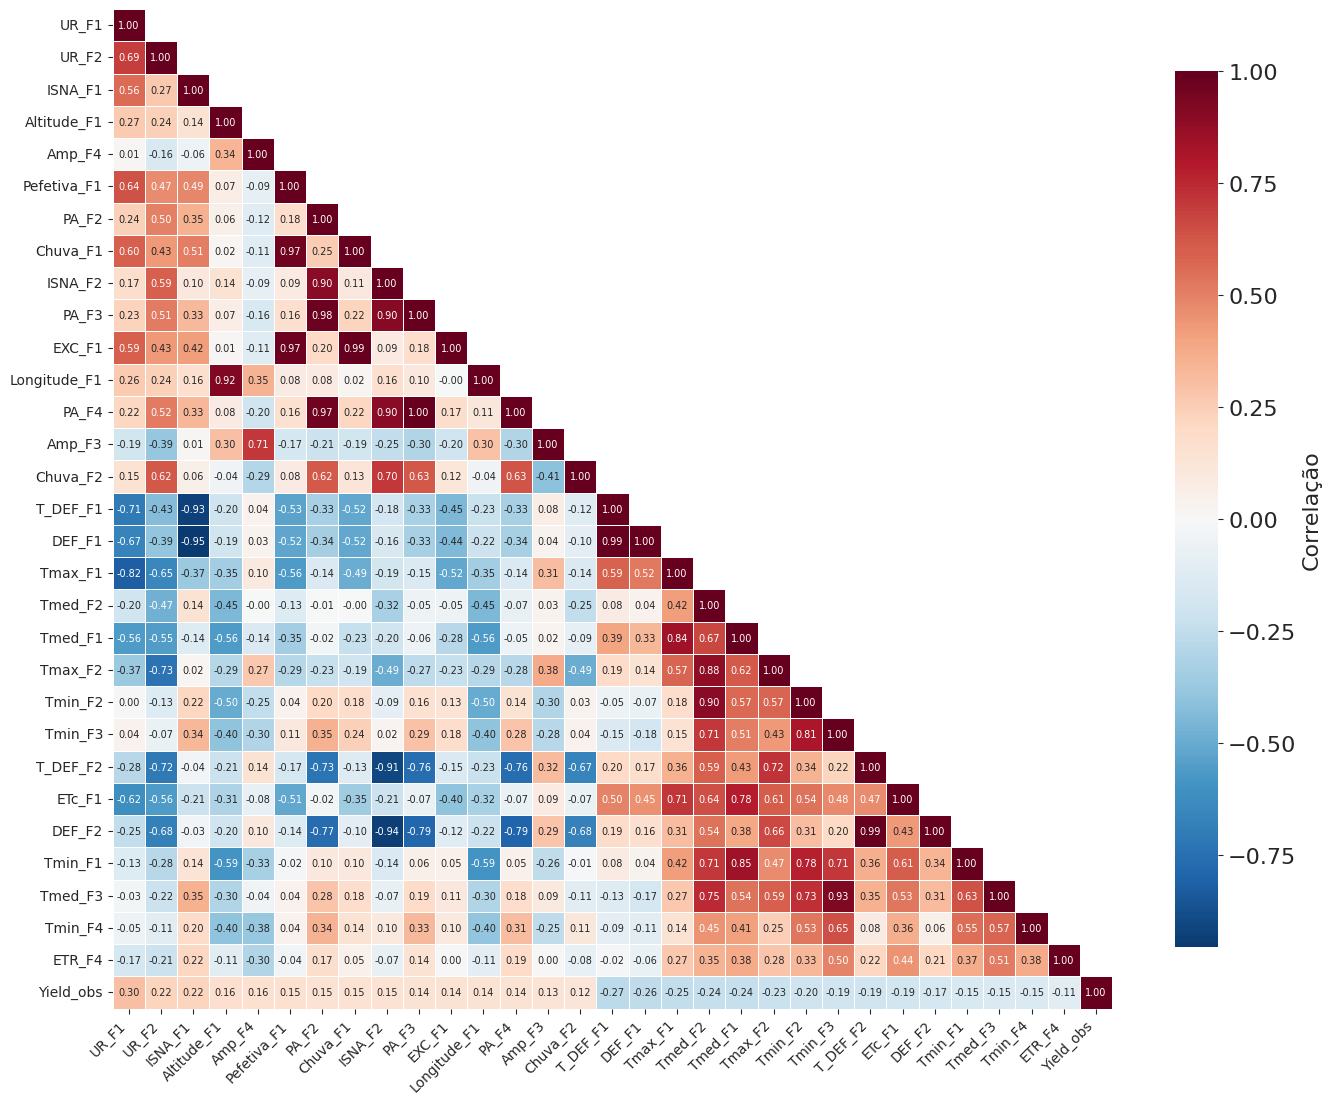

In [21]:
### TOP 30 Variáveis #####
# Seleciona apenas as variáveis mais correlacionadas (top 15 positivas e top 15 negativas)
corr_completa = df_wide.corr(numeric_only=True)['Yield_obs'].drop('Yield_obs')
top_pos = corr_completa.nlargest(15)  # Top 15 correlações positivas
top_neg = corr_completa.nsmallest(15)  # Top 15 correlações negativas
variaveis_selecionadas = list(top_pos.index) + list(top_neg.index)

# Matriz de correlação apenas com as variáveis selecionadas
corr_matrix = df_wide[variaveis_selecionadas + ['Yield_obs']].corr(numeric_only=True)

# Cria o heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Mascara para mostrar só metade

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,  # Mostra os valores
            fmt='.2f',
            cmap='RdBu_r',  # Vermelho para negativo, azul para positivo
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlação"},
            annot_kws={'size': 7},
            ax=ax)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

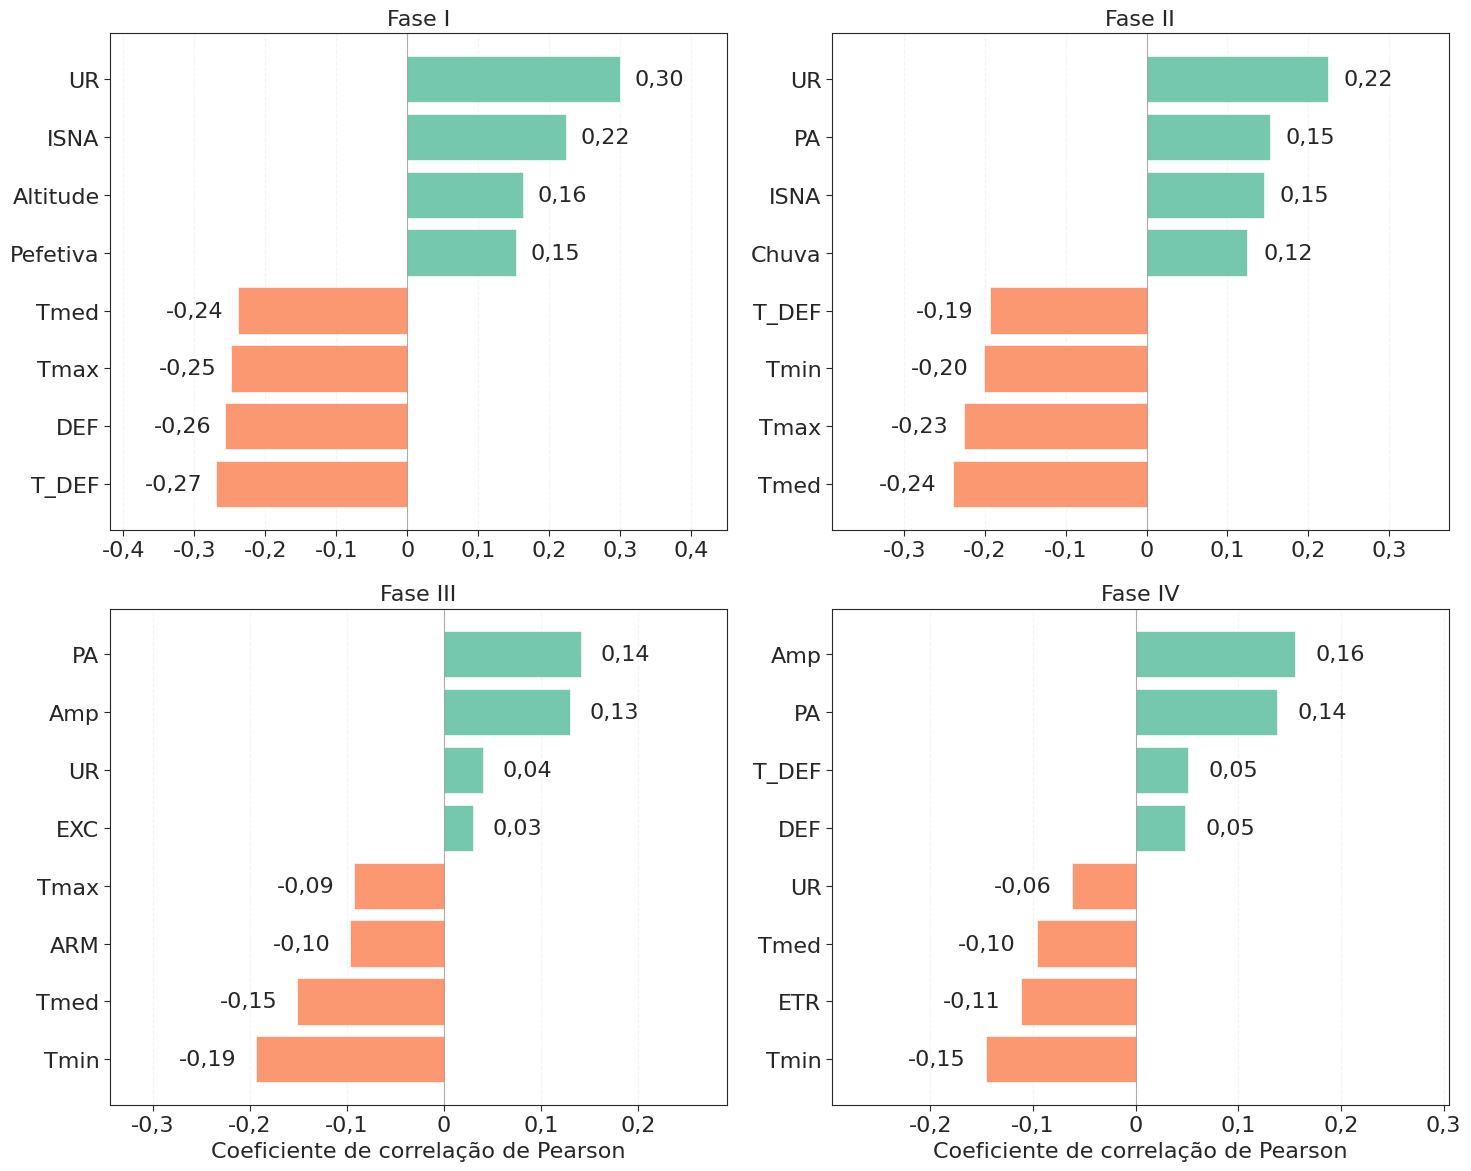

In [32]:
# Calcula correlação e prepara dados
corr = df_wide.corr(numeric_only=True)['Yield_obs'].drop('Yield_obs')

# Cria DataFrame com informações de fase
corr_df = pd.DataFrame({
    'variavel': corr.index,
    'correlacao': corr.values,
    'fase': [var.split('_F')[1][0] if '_F' in var else '0' for var in corr.index],
    'var_base': [var.split('_F')[0] if '_F' in var else var for var in corr.index]
})

# =========================================================
# CONFIGURAÇÃO DE ESTILO
# =========================================================
sns.set_style("ticks")

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'axes.labelweight': 'normal', # Sem negrito
    'axes.titleweight': 'normal'  # Sem negrito
})

# Mapeamento de nomes das fases
mapa_fases = {
    '1': 'Fase I',
    '2': 'Fase II',
    '3': 'Fase III',
    '4': 'Fase IV'
}

# =========================================================
# PREPARAÇÃO DO GRÁFICO
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Cores mais "bonitas" e profissionais (Verde água e Coral suave)
cor_positiva = '#66c2a5' # Soft Green
cor_negativa = '#fc8d62' # Soft Orange/Coral

for idx, fase_num in enumerate(['1', '2', '3', '4']):
    ax = axes[idx]

    # Filtra e prepara dados da fase
    dados_fase = corr_df[corr_df['fase'] == fase_num].copy()

    if len(dados_fase) > 0:
        # Seleciona os 4 maiores e 4 menores (Top 8 impacto)
        top = dados_fase.nlargest(4, 'correlacao')
        bottom = dados_fase.nsmallest(4, 'correlacao')
        dados_plot = pd.concat([bottom, top]).drop_duplicates().sort_values('correlacao')

        # Aplica cores baseadas no valor
        colors = [cor_negativa if x < 0 else cor_positiva for x in dados_plot['correlacao']]

        # Gráfico de barras horizontais
        bars = ax.barh(range(len(dados_plot)), dados_plot['correlacao'],
                       color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)

        # Linha central zero
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

        # Configuração de Eixos
        ax.set_yticks(range(len(dados_plot)))
        ax.set_yticklabels(dados_plot['var_base'].values)
        ax.set_title(mapa_fases[fase_num])

        # Lógica para exibir o X-label apenas na linha de baixo (índices 2 e 3)
        if idx >= 2:
          ax.set_xlabel('Coeficiente de correlação de Pearson')
        else:
          ax.set_xlabel('')

        # Formatação do eixo X com VÍRGULA
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:g}'.replace('.', ',')))

        # Adiciona os valores nas barras com VÍRGULA
        for i, v in enumerate(dados_plot['correlacao']):
            text_val = f'{v:.2f}'.replace('.', ',')
            offset = 0.02 if v >= 0 else -0.02
            ha = 'left' if v >= 0 else 'right'
            ax.text(v + offset, i, text_val, va='center', ha=ha, fontsize=16)

        # Ticks profissionais
        ax.tick_params(axis='both', which='both', direction='out', length=4,
                       bottom=True, left=True, top=False, right=False)

        # Limites do eixo X para dar respiro aos números
        ax.set_xlim(dados_plot['correlacao'].min() - 0.15, dados_plot['correlacao'].max() + 0.15)
        ax.grid(axis='x', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

In [40]:
# 1. Criar uma cópia formatada para análise
df_analise_corr = corr_df.copy()

# 2. Adicionar o nome da fase para facilitar a leitura
df_analise_corr['fase_nome'] = df_analise_corr['fase'].map(mapa_fases)

# 3. Adicionar uma coluna de 'Impacto Absoluto' (para ordenar pela força da relação, indep. do sinal)
df_analise_corr['impacto_abs'] = df_analise_corr['correlacao'].abs()

# 4. Criar o DataFrame final ordenado por Fase e Força de Correlação
# Vamos focar nas variáveis que realmente importam (ex: correlação > 0.3 ou < -0.3)
df_ranking = df_analise_corr.sort_values(['fase', 'impacto_abs'], ascending=[True, False])

# 5. Selecionar e renomear colunas para um relatório limpo
df_final = df_ranking[['fase_nome', 'var_base', 'correlacao']].copy()
df_final.columns = ['Fase', 'Variável', 'Coef. Pearson']

# Exibir os top 5 de cada fase para análise rápida
df_r_fase = df_final.groupby('Fase').head(5)

# 6. Exportar
df_r_fase.to_excel('correlacoes_produtividade_fases.xlsx', index=False)
df_r_fase

,Fase,Variável,Coef. Pearson
61,Fase I,UR,0.300367
45,Fase I,T_DEF,-0.269047
15,Fase I,DEF,-0.256200
49,Fase I,Tmax,-0.249016
53,Fase I,Tmed,-0.239205
54,Fase II,Tmed,-0.239596
50,Fase II,Tmax,-0.225530
62,Fase II,UR,0.224210
58,Fase II,Tmin,-0.200719
46,Fase II,T_DEF,-0.193853


# **Teste de aplicação das variáveis**
---

In [48]:
X = df_wide[todas.index]
y = df_wide['Yield_obs']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Modelo com parâmetros padrão
model = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('R2:', r2)
print('RMSE:', rmse)
print('MAE:', mae)

R2: 0.6990507112221096
RMSE: 453.8562956380191
MAE: 331.24592519788825


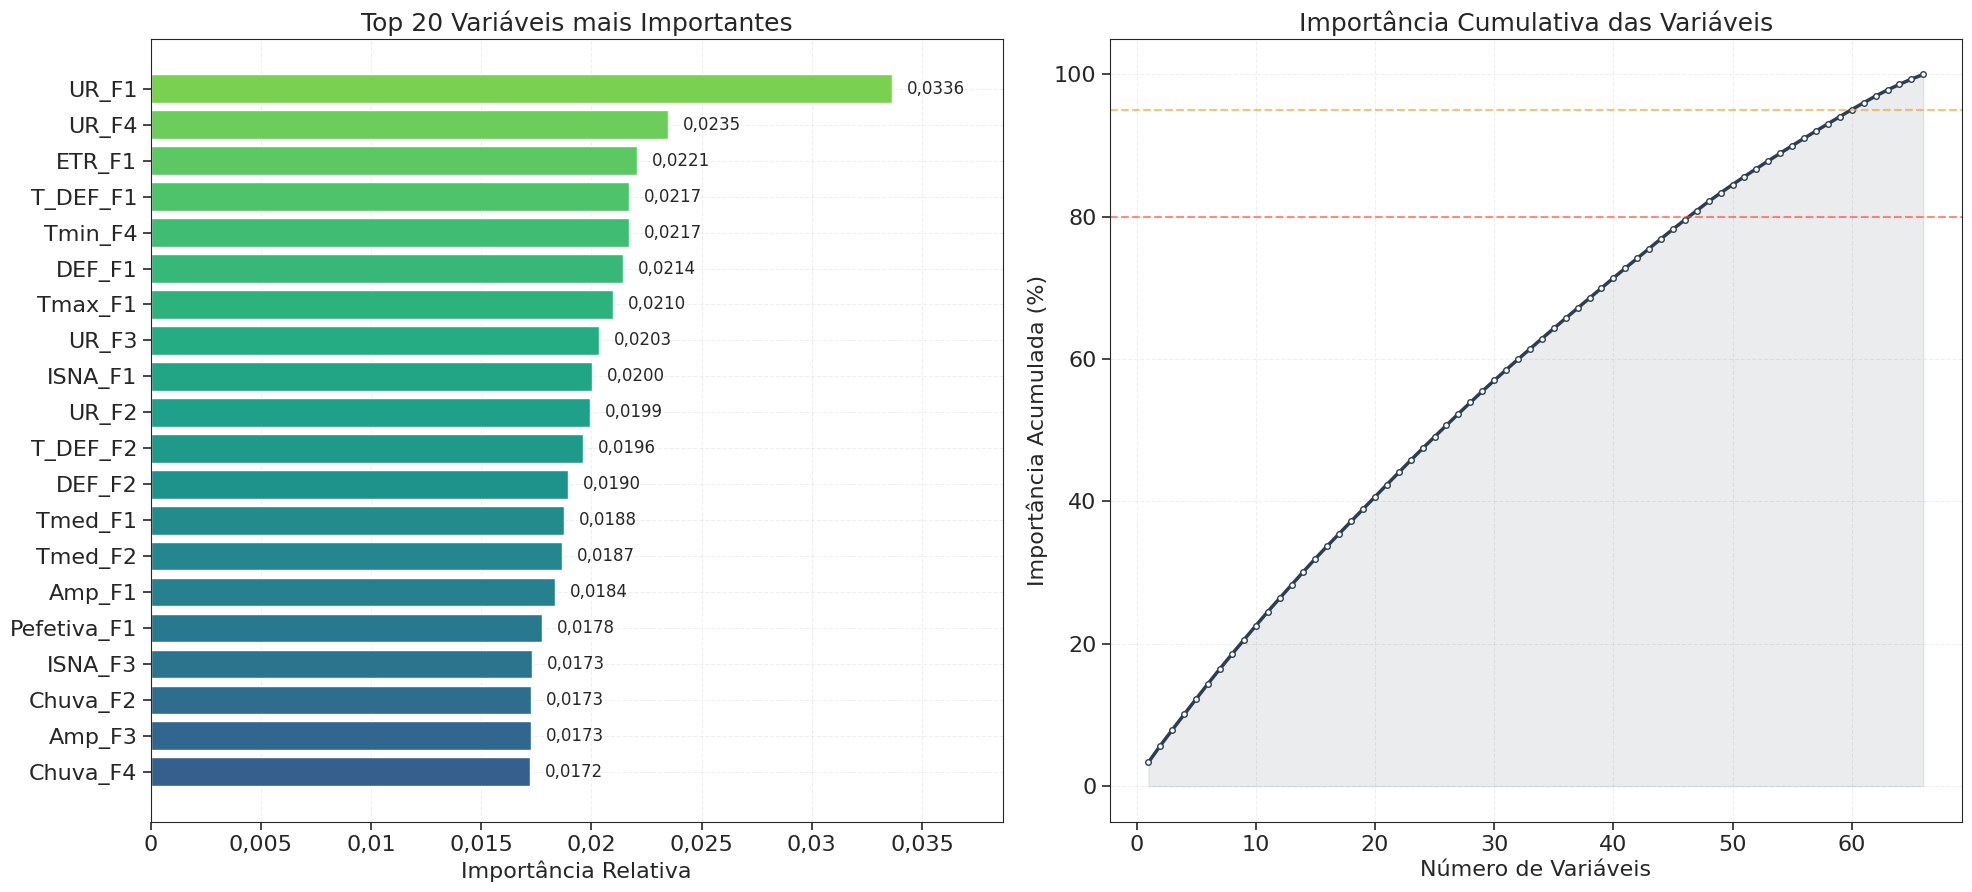

In [62]:
# =========================================================
# CONFIGURAÇÃO DE ESTILO
# =========================================================
sns.set_style("ticks")
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal'
})

# Preparação dos dados
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df['cumulative'] = importance_df['importance'].cumsum()

# =========================================================
# CRIAÇÃO DO PAINEL (1x2)
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10)) # Aumentei um pouco a largura

# --- GRÁFICO 1: IMPORTÂNCIA INDIVIDUAL ---
top_20 = importance_df.head(20).copy().iloc[::-1]
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(top_20)))

bars = ax1.barh(top_20['feature'], top_20['importance'],
                color=colors, edgecolor='white', linewidth=1)

ax1.set_title('Top 20 Variáveis mais Importantes')
ax1.set_xlabel('Importância Relativa')
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:g}'.replace('.', ',')))

# AJUSTE: Aumentar o limite do eixo X em 15% para o número não fugir
ax1.set_xlim(0, top_20['importance'].max() * 1.15)

for i, v in enumerate(top_20['importance']):
    ax1.text(v + (top_20['importance'].max()*0.02), i, f'{v:.4f}'.replace('.', ','),
             va='center', fontsize=12)

# --- GRÁFICO 2: IMPORTÂNCIA CUMULATIVA ---
x_cum = np.arange(1, len(importance_df) + 1)
y_cum = importance_df['cumulative'].values * 100

ax2.plot(x_cum, y_cum, color='#2c3e50', linewidth=2.5, marker='o', markersize=4, markerfacecolor='white')
ax2.fill_between(x_cum, y_cum, color='#34495e', alpha=0.1)

ax2.axhline(y=80, color='#e74c3c', linestyle='--', alpha=0.6)
ax2.axhline(y=95, color='#f39c12', linestyle='--', alpha=0.6)

n_80 = (importance_df['cumulative'] <= 0.8).sum()
n_95 = (importance_df['cumulative'] <= 0.95).sum()

ax2.set_title('Importância Cumulativa das Variáveis')
ax2.set_xlabel('Número de Variáveis')
ax2.set_ylabel('Importância Acumulada (%)')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:g}'.replace('.', ',')))

# AJUSTE: Mover o texto para a direita (x=n_80 + 2) e garantir que fiquem dentro do gráfico
#ax2.text(n_80 + 2, 72, f'{n_80} variáveis explicam 80%', color='#e74c3c', fontsize=14)
#ax2.text(n_95 + 2, 87, f'{n_95} variáveis explicam 95%', color='#f39c12', fontsize=14)

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='both', direction='out', length=6, width=1.2,
                   bottom=True, left=True, top=False, right=False)
    ax.grid(axis='both', linestyle='--', alpha=0.3)


# AJUSTE: tight_layout com rect para reservar espaço ao título superior
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

In [63]:
# 1. Criar o DataFrame base com as importâncias do modelo
df_interpretacao = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia_Relativa': model.feature_importances_
})

# 2. Ordenar do maior para o menor impacto
df_interpretacao = df_interpretacao.sort_values('Importancia_Relativa', ascending=False).reset_index(drop=True)

# 3. Calcular a Importância Acumulada (%)
df_interpretacao['Importancia_Acumulada_Perc'] = df_interpretacao['Importancia_Relativa'].cumsum() * 100

# 4. Adicionar uma coluna de "Rank"
df_interpretacao.insert(0, 'Rank', df_interpretacao.index + 1)

# 5. Criar uma coluna de "Classificacao" baseada no impacto (Pareto 80/20)
def classificar(acumulado):
    if acumulado <= 80: return 'Alta Relevância (Top 80%)'
    if acumulado <= 95: return 'Relevância Moderada (95%)'
    return 'Baixa Contribuição'

df_interpretacao['Categoria_Pareto'] = df_interpretacao['Importancia_Acumulada_Perc'].apply(classificar)

# =========================================================
# EXIBIÇÃO CORRIGIDA (Sem o erro 'Styler object has no attribute replace')
# =========================================================

# Usamos o argumento 'decimal' dentro do format para exibir com vírgula no Colab
styled_df = df_interpretacao.head(20).style.format({
    'Importancia_Relativa': '{:.4f}',
    'Importancia_Acumulada_Perc': '{:.2f}%'
}, decimal=',')

# 6. Exportar
styled_df.to_excel('pareto.xlsx', index=False)
styled_df

,Rank,Variavel,Importancia_Relativa,Importancia_Acumulada_Perc,Categoria_Pareto
0,1,UR_F1,"0,0336","3,36%",Alta Relevância (Top 80%)
1,2,UR_F4,"0,0235","5,71%",Alta Relevância (Top 80%)
2,3,ETR_F1,"0,0221","7,92%",Alta Relevância (Top 80%)
3,4,T_DEF_F1,"0,0217","10,09%",Alta Relevância (Top 80%)
4,5,Tmin_F4,"0,0217","12,26%",Alta Relevância (Top 80%)
5,6,DEF_F1,"0,0214","14,41%",Alta Relevância (Top 80%)
6,7,Tmax_F1,"0,0210","16,50%",Alta Relevância (Top 80%)
7,8,UR_F3,"0,0203","18,54%",Alta Relevância (Top 80%)
8,9,ISNA_F1,"0,0200","20,54%",Alta Relevância (Top 80%)
9,10,UR_F2,"0,0199","22,53%",Alta Relevância (Top 80%)


#Covariáveis ML

In [45]:
import pandas as pd

# Criando o dicionário com as informações das variáveis
variaveis_dict = {
    'Variável': [
        # Variáveis climáticas básicas
        'Tmin_F1 a F4', 'Tmax_F1 a F4', 'Tmed_F1 a F4', 'Chuva_F1 a F4',
        'UR_F1 a F4', 'ETc_F1 a F4', 'ETR_F1 a F4', 'ARM_F1 a F4',
        'DEF_F1 a F4', 'EXC_F1 a F4', 'ISNA_F1 a F4', 'PA_F1 a F4',
        # Variáveis derivadas (feature engineering)
        'Amp_F1 a F4', 'Pefetiva_F1 a F4', 'T_DEF_F1 a F4',
        # Variáveis espaciais
        'Latitude', 'Longitude', 'Altitude', 'lat_lon',
        # Variáveis temporais
        'DOY_semeadura', 'DOY_maturacao',
        # Variável alvo
        'Yield_obs'
    ],
    'Descrição': [
        'Temperatura mínima (°C) em cada fase fenológica',
        'Temperatura máxima (°C) em cada fase fenológica',
        'Temperatura média (°C) em cada fase fenológica',
        'Precipitação acumulada (mm) em cada fase fenológica',
        'Umidade relativa (%) em cada fase fenológica',
        'Evapotranspiração da cultura (mm) em cada fase fenológica',
        'Evapotranspiração real (mm) em cada fase fenológica',
        'Armazenamento de água no solo (mm) em cada fase fenológica',
        'Déficit hídrico (mm) em cada fase fenológica',
        'Excesso hídrico (mm) em cada fase fenológica',
        'Índice de estresse hídrico em cada fase fenológica',
        'Precipitação acumulada (mm) em cada fase fenológica',
        'Amplitude térmica (Tmax - Tmin) (°C) em cada fase fenológica',
        'Precipitação efetiva (Chuva/ETc) em cada fase fenológica',
        'Interação entre temperatura máxima e déficit hídrico (°C × mm) em cada fase fenológica',
        'Latitude do município (graus decimais)',
        'Longitude do município (graus decimais)',
        'Altitude do município (m)',
        'Interação espacial (Latitude × Longitude)',
        'Dia do ano da semeadura',
        'Dia do ano da maturação',
        'Produtividade observada (kg/ha) - Variável Alvo'
    ],
    'Unidade': [
        '°C', '°C', '°C', 'mm', '%', 'mm', 'mm', 'mm', 'mm', 'mm', 'adimensional', 'mm',
        '°C', 'adimensional', '°C × mm',
        'graus decimais', 'graus decimais', 'm', 'graus²',
        'dias', 'dias',
        'kg/ha'
    ],
    'Tipo': [
        'Preditora', 'Preditora', 'Preditora', 'Preditora', 'Preditora', 'Preditora',
        'Preditora', 'Preditora', 'Preditora', 'Preditora', 'Preditora', 'Preditora',
        'Preditora', 'Preditora', 'Preditora',
        'Preditora', 'Preditora', 'Preditora', 'Preditora',
        'Preditora', 'Preditora',
        'Predita'
    ],
    'Fase': [
        'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4',
        'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4',
        'F1-F4', 'F1-F4', 'F1-F4',
        'Todas', 'Todas', 'Todas', 'Todas',
        'Todas', 'Todas',
        '-'
    ]
}

# Criando DataFrame da tabela
df_tabela = pd.DataFrame(variaveis_dict)

# Exibindo a tabela formatada
print(df_tabela.to_string(index=False))


        Variável                                                                              Descrição        Unidade      Tipo  Fase
    Tmin_F1 a F4                                        Temperatura mínima (°C) em cada fase fenológica             °C Preditora F1-F4
    Tmax_F1 a F4                                        Temperatura máxima (°C) em cada fase fenológica             °C Preditora F1-F4
    Tmed_F1 a F4                                         Temperatura média (°C) em cada fase fenológica             °C Preditora F1-F4
   Chuva_F1 a F4                                    Precipitação acumulada (mm) em cada fase fenológica             mm Preditora F1-F4
      UR_F1 a F4                                           Umidade relativa (%) em cada fase fenológica              % Preditora F1-F4
     ETc_F1 a F4                              Evapotranspiração da cultura (mm) em cada fase fenológica             mm Preditora F1-F4
     ETR_F1 a F4                                    Eva

In [46]:
# Criando o DataFrame com as variáveis
data = {
    'Variável': [
        # Variáveis climáticas básicas
        'Tmin', 'Tmax', 'Tmed', 'Chuva',
        'UR', 'ETc', 'ETR', 'ARM',
        'DEF', 'EXC', 'ISNA', 'PA',
        # Variáveis derivadas
        'Amp', 'Pefetiva', 'T_DEF',
        # Variáveis espaciais
        'Latitude_F1', 'Longitude_F1', 'Altitude_F1', 'lat_lon_F1',
        # Variáveis temporais
        'DOY_semeadura', 'DOY_maturacao',
        # Variável alvo
        'Yield_obs'
    ],
    'Descrição': [
        'Temperatura mínima',
        'Temperatura máxima',
        'Temperatura média',
        'Precipitação acumulada',
        'Umidade relativa',
        'Evapotranspiração da cultura',
        'Evapotranspiração real',
        'Armazenamento de água no solo',
        'Déficit hídrico',
        'Excedente hídrico',
        'Índice de satisfação das necessidades de água',
        'Precipitação acumulada',
        'Amplitude térmica (Tmax - Tmin)',
        'Precipitação efetiva (Chuva/ETc)',
        'Temperatura máxima × déficit hídrico',
        'Latitude do município',
        'Longitude do município',
        'Altitude do município',
        'Interação espacial (Latitude × Longitude)',
        'Dia do ano da semeadura',
        'Dia do ano da maturação',
        'Produtividade observada'
    ],
    'Unidade': ['°C', '°C', '°C', 'mm', '%', 'mm', 'mm', 'mm', 'mm', 'mm',
                '-', 'mm', '°C', '-', '°C×mm',
                '°', '°', 'm', '°²',
                'DOY', 'DOY', 'kg ha⁻¹'],
    'Fase': [
        'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4',
        'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4',
        'F1-F4', 'F1-F4', 'F1-F4', 'F1-F4',
        'F1-F4', 'F1-F4', 'F1-F4',
        'F1', 'F1', 'F1', 'F1', # Mudança aqui: Fase para espacial
        'Todas', 'Todas',
        '-'
    ]
}

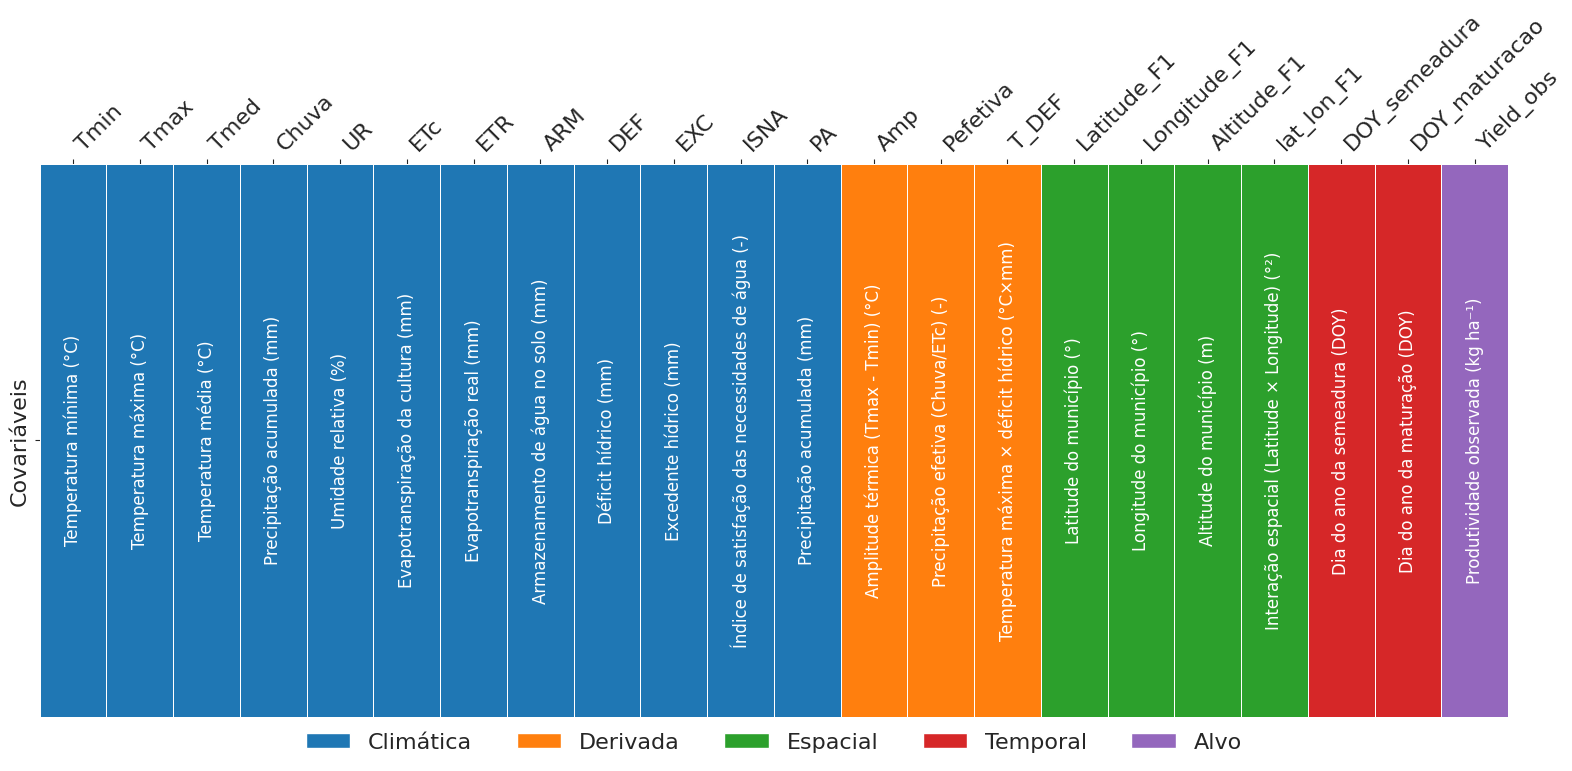

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# 1. DATAFRAME
# ============================

df_vars = pd.DataFrame(data)

# ============================
# 2. CLASSIFICAÇÃO
# ============================

def classificar_variavel(var):
    if var in ['Latitude_F1', 'Longitude_F1', 'Altitude_F1', 'lat_lon_F1']:
        return 'Espacial'
    elif var in ['DOY_semeadura', 'DOY_maturacao']:
        return 'Temporal'
    elif var in ['Amp', 'Pefetiva', 'T_DEF']:
        return 'Derivada'
    elif var == 'Yield_obs':
        return 'Alvo'
    else:
        return 'Climática'

df_vars['Tipo'] = df_vars['Variável'].apply(classificar_variavel)

# ============================
# 3. TEXTO (descrição + unidade)
# ============================

df_vars['Texto'] = df_vars['Descrição'] + ' (' + df_vars['Unidade'] + ')'
df_vars['Texto'] = df_vars['Texto'].str.wrap(50)

# ============================
# 4. MAPA NUMÉRICO
# ============================

mapa_tipo = {
    'Climática': 0,
    'Derivada': 1,
    'Espacial': 2,
    'Temporal': 3,
    'Alvo': 4
}

cores = {
    'Climática': '#1f77b4',
    'Derivada': '#ff7f0e',
    'Espacial': '#2ca02c',
    'Temporal': '#d62728',
    'Target': '#9467bd'
}

df_vars['Tipo_num'] = df_vars['Tipo'].map(mapa_tipo)

# ============================
# 5. HEATMAP HORIZONTAL
# ============================

plt.figure(figsize=(16, 8))

ax = sns.heatmap(
    df_vars[['Tipo_num']].T,  # 👈 horizontal
    cmap=sns.color_palette(list(cores.values())),
    cbar=False,
    linewidths=0.5,
    annot=df_vars['Texto'].values.reshape(1, -1),
    fmt='',
    annot_kws={"size": 12, "rotation": 90}
)
ax.set_yticklabels(['Covariáveis'], rotation=90, fontsize=16)

# eixo X = variáveis (símbolos)
# colocar ticks no topo
ax.xaxis.tick_top()

# POSIÇÃO CORRETA (centro das células)
ax.set_xticks([i + 0.5 for i in range(len(df_vars))])

# rótulos
ax.set_xticklabels(df_vars['Variável'], rotation=45, fontsize = 16, ha='left')

# remover ticks de baixo
ax.tick_params(bottom=False)

# ============================
# 6. LEGENDA
# ============================

legend_elements = [
    Patch(facecolor=cores['Climática'], label='Climática'),
    Patch(facecolor=cores['Derivada'], label='Derivada'),
    Patch(facecolor=cores['Espacial'], label='Espacial'),
    Patch(facecolor=cores['Temporal'], label='Temporal'),
    Patch(facecolor=cores['Target'], label='Alvo')
]

plt.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),  # controla a altura
    ncol=5,  # uma linha com 5 itens
    frameon=False
)

plt.tight_layout()
plt.show()